# Chapter 11: The Mathematics of Curiosity

A controller has two tools and limited opportunities to learn which one works more often. Always choosing the current favorite can waste the budget if early evidence was misleading. Always exploring can waste it even after the better tool is apparent. Curiosity is therefore a resource decision, not an unlimited appetite for information.

This notebook compares three finite policies against a constructed Bernoulli world. The true arm means are supplied to the simulator for scoring, while each policy chooses using its own observed successes. The chart measures pseudo-regret rather than presenting a lucky reward trace as proof of superiority. Change the arm ordering and seed before drawing a policy conclusion.

**Outcome:** Compare greedy, UCB, and Thompson choices in a declared stationary bandit.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

After n_a pulls and s_a successes, the empirical mean is s_a/n_a. Greedy choice selects the largest empirical mean. UCB adds an exploration bonus sqrt(2 ln t / n_a), where t is the number of completed pulls (Equation 11.2 with c equal to the square root of two), favoring arms whose uncertainty remains large relative to their evidence.

Thompson sampling uses a Beta(1,1) prior for each Bernoulli arm. Its posterior is Beta(s_a+1,n_a-s_a+1). Each round draws one candidate mean from each posterior and chooses the largest draw. A posterior sample is a decision device, not a certificate that an arm's true mean equals that sampled value.

Cumulative pseudo-regret is sum_t [max_a mu_a-mu_(A_t)]. It uses the simulator's known means and measures expected reward forgone by choices. Realized net reward sums observed zero/one outcomes minus pull costs. These differ because sampling noise can favor a worse arm in a finite run. Information value is another quantity: it prices how evidence improves a future decision, not the historical cumulative shortfall.

A separate one-pull information calculation uses the final Beta posterior. For each possible sampled arm, it averages the best posterior mean after a hypothetical success or failure, then subtracts the best current posterior mean. The net value also subtracts one pull cost. This is the Bayesian value of information for one later arm choice, not cumulative regret or a recommendation to continue the original budget.

## Apply this to an agent

An agent trying several tools must spend some actions learning which tool works best. Compare exploration choices under the same constructed stationary task. The known reward means are a teaching oracle, not information ordinarily available to the controller.

## A calculation you can run

Supply arm means, a finite round budget, seed, and common pull cost. Each policy initializes untried arms once while budget remains, then uses its own decision rule. The simulator samples outcomes with a local seeded random generator, preserving offline reproducibility without modifying global random state.

The report gives pull counts, successes, pseudo-regret, and realized net reward for all policies. Curves show cumulative pseudo-regret by round. They are nondecreasing because each known-mean shortfall is nonnegative. Compare how frequently each policy visits the better arm, but do not rank policies statistically from a single seed. The changed case swaps means, testing whether early sampling and tie order affect the finite outcome.

The returned policy table also contains posterior means and gross/net one-pull information values. Inspect those separately from the regret chart: a policy can have accumulated regret even when an additional observation no longer changes its preferred action.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 11
inputs = {'means': [0.4, 0.7], 'rounds': 120, 'seed': 7, 'pull_cost': 0.05}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 11: bounded-exploration
How much does a finite exploration policy pay to learn which action is better?
Evidence: constructed teaching example

Calculated quantities:
{
  "policies": {
    "greedy": {
      "counts": [
        2,
        118
      ],
      "successes": [
        1,
        89
      ],
      "cumulative_pseudo_regret": 0.6,
      "net_observed_reward": 84.0,
      "posterior_means": [
        0.5,
        0.75
      ],
      "one_pull_gross_information_value": [
        0.0,
        0.0
      ],
      "one_pull_net_information_value": [
        -0.05,
        -0.05
      ]
    },
    "ucb": {
      "counts": [
        31,
        89
      ],
      "successes": [
        16,
        67
      ],
      "cumulative_pseudo_regret": 9.3,
      "net_observed_reward": 77.0,
      "posterior_means": [
        0.5151515152,
        0.7472527473
      ],
      "one_pull_gross_information_value": [
        0.0,
        0.0
      ],
      "one_pull_net_information_value": [
 

In the default world, the optimal mean is 0.7 and the other arm's mean is 0.4. Every pull of the worse arm contributes 0.3 pseudo-regret; a pull of the best contributes zero. Therefore each policy's final regret must equal 0.3 times its worse-arm pull count, independent of realized successes.

The common cost 0.05 changes net observed reward but not pseudo-regret between arms, because it applies equally to every pull. The changed world reverses which arm is optimal. Counts and trajectories can change substantially even though the mean gap stays 0.3. That is a finite exploration diagnostic, not an empirical result about real tools.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


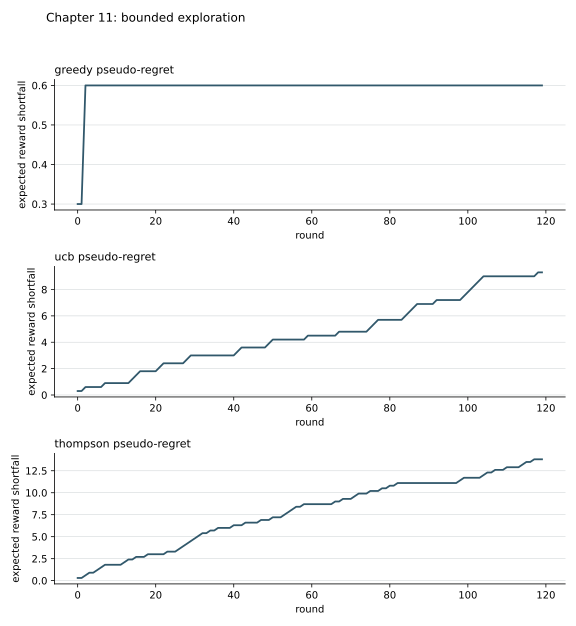

In [3]:
display(SVG(figure_svg(report)))

**Figure 11.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

Stationarity is a central assumption. If an arm's success probability changes with time, task type, or another agent's behavior, the single mean no longer describes the process. A policy can then look stubborn because its accumulated evidence belongs to a different world.

The seeded comparison also does not provide a confidence interval for policy performance. Policies consume random numbers differently, especially Thompson sampling, so the same seed is a reproducibility device rather than perfectly matched outcome exposure. Use repeated independently declared seeds and a suitable comparison design for statistical claims.

A simulator oracle is not a deployed capability. Real logs usually do not reveal the true means needed for pseudo-regret. When those means are unavailable, report observed reward and an evaluation design instead of treating empirical averages as known truths.

Chapter 11: bounded-exploration
How much does a finite exploration policy pay to learn which action is better?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "policies": {
    "greedy": {
      "counts": [
        110,
        10
      ],
      "successes": [
        81,
        7
      ],
      "cumulative_pseudo_regret": 3.0,
      "net_observed_reward": 82.0,
      "posterior_means": [
        0.7321428571,
        0.6666666667
      ],
      "one_pull_gross_information_value": [
        0.0,
        0.0
      ],
      "one_pull_net_information_value": [
        -0.05,
        -0.05
      ]
    },
    "ucb": {
      "counts": [
        95,
        25
      ],
      "successes": [
        71,
        11
      ],
      "cumulative_pseudo_regret": 7.5,
      "net_observed_reward": 76.0,
      "posterior_means": [
        0.7422680412,
        0.4444444444
      ],
      "one_pull_gross_information_value": [
        0.0,
        0.0
      ],
      "one_pull

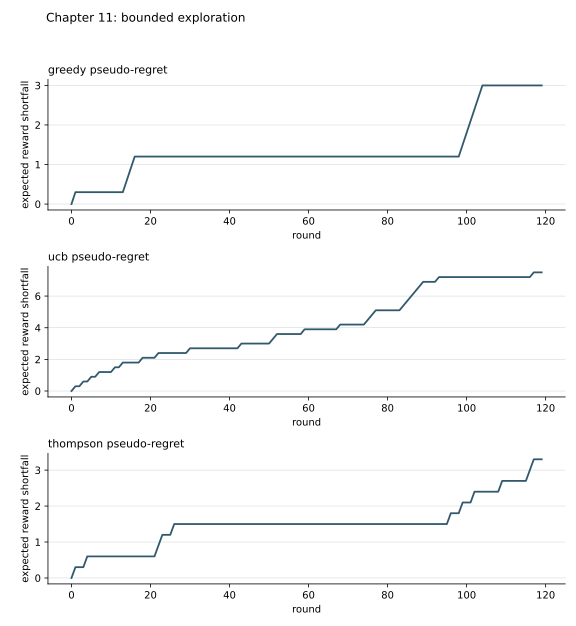

In [4]:
changed_inputs = {'means': [0.7, 0.4], 'rounds': 120, 'seed': 7, 'pull_cost': 0.05}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 11.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer problem has three arms, with gaps 0.6,0.3,0 relative to the best mean 0.8. Its pseudo-regret must equal 0.6 n_0+0.3 n_1. Check that identity against each returned count vector.

For a local exploration plan, specify budget, outcome predicate, arm availability, and the evidence supporting stationarity. Different tool costs require an extended objective rather than the equal-cost comparison here. Keep exploration expense separate from any proposed value-of-information calculation. If the real task asks whether one extra observation is worthwhile, use the belief and information method rather than relabeling regret.

In [5]:
transfer_inputs = {'means': [0.2, 0.5, 0.8], 'rounds': 90, 'seed': 19, 'pull_cost': 0.1}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 11: bounded-exploration
How much does a finite exploration policy pay to learn which action is better?
Evidence: constructed transfer example

Calculated quantities:
{
  "policies": {
    "greedy": {
      "counts": [
        1,
        1,
        88
      ],
      "successes": [
        0,
        0,
        78
      ],
      "cumulative_pseudo_regret": 0.9,
      "net_observed_reward": 69.0,
      "posterior_means": [
        0.3333333333,
        0.3333333333,
        0.8777777778
      ],
      "one_pull_gross_information_value": [
        0.0,
        0.0,
        0.0
      ],
      "one_pull_net_information_value": [
        -0.1,
        -0.1,
        -0.1
      ]
    },
    "ucb": {
      "counts": [
        9,
        25,
        56
      ],
      "successes": [
        2,
        16,
        48
      ],
      "cumulative_pseudo_regret": 12.9,
      "net_observed_reward": 57.0,
      "posterior_means": [
        0.2727272727,
        0.6296296296,
        0.8448275862


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **means:** Arm success probabilities in [0,1], known only to this constructed simulator.
- **rounds:** Integer pull budget 1..10000.
- **seed:** Nonnegative integer random seed.
- **pull_cost:** Nonnegative common cost per pull.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch11.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 11: bounded-exploration
How much does a finite exploration policy pay to learn which action is better?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "policies": {
    "greedy": {
      "counts": [
        1,
        1,
        88
      ],
      "successes": [
        0,
        0,
        78
      ],
      "cumulative_pseudo_regret": 0.9,
      "net_observed_reward": 69.0,
      "posterior_means": [
        0.3333333333,
        0.3333333333,
        0.8777777778
      ],
      "one_pull_gross_information_value": [
        0.0,
        0.0,
        0.0
      ],
      "one_pull_net_information_value": [
        -0.1,
        -0.1,
        -0.1
      ]
    },
    "ucb": {
      "counts": [
        9,
        25,
        56
      ],
      "successes": [
        2,
        16,
        48
      ],
      "cumulative_pseudo_regret": 12.9,
      "net_observed_reward": 57.0,
      "posterior_means": [
        0.2727272727,
        0.6

## Explore the four chapter demonstrations

The following sections reproduce every demonstration in the illustrated chapter reader. They use the same declared controls, calculation and figure. Begin with the prediction, run the worked case, change one control, then inspect the complete state table. The chapter experiment above remains available for your own compatible inputs.

In [7]:
from math_ai_agents.demos import demo_catalog, demo_states, run_demo, demo_report_text

<a id="demo-c11-d01"></a>

### Demonstration 1: Regret: what never looking again costs

How fast does the shortfall against an all-knowing agent grow under the rules that always exploit, always rotate, explore with optimism or sample from a belief?

![Equation 11.1](../assets/math/0748ee3073daf997794a.svg)

**Symbols and units:** T is the number of tasks. mu-star is the success probability of the best arm (tool). mu of a_t is the success probability of the arm chosen at task t, and E is the average over luck. Regret is the total successes forgone compared with always using the best arm; for a run it equals the sum, over arms, of the gap to the best mean times the pulls of that arm. Worlds: the book's tools (A 0.78, B 0.90, 1,000 tasks), the notebook's default (0.4 and 0.7, 120 tasks), its swapped case (0.7 and 0.4) and its three-arm case (0.2, 0.5 and 0.8, 90 tasks). Each curve is one seeded run.

Taking the worse arm every time forgoes the gap on every task, so regret is the gap times T, a straight line; rotating evenly forgoes the average gap, a straight line half as steep for two arms. The optimistic rule and posterior sampling keep trying a thin-record arm only while it is still uncertain, so their regret flattens relative to the lines. The right panel shows why: regret is the sum of gap x pulls, so it is made only of pulls of arms that are not best. A seeded run is not an average: always taking the current best can look best when its first pulls happen to find the best arm.

**Use in this chapter:** When a team reports a success rate for a deployed agent, ask how much of its action set it has sampled recently. Regret itself needs the true means, which a deployed agent does not have, so this is the question that can be asked. An agent that took one action thousands of times and the alternatives twice may have stopped measuring.

**Assumptions:** Independent fixed success probabilities and one seeded run per rule, so each curve is one draw of luck: it is not a policy performance estimate and not the expectation in Equation (11.1). The table's 200-seed means describe this constructed world; they do not estimate performance in a deployed environment. Regret here is pseudo-regret, computed from the known means, which a deployed agent does not have. The stuck and rotate lines are closed forms. Real tools change over time, which this model does not cover.

**Predict before running:** In the book's world, go from the run of 1,000 tasks to the ten-times-longer run of 10,000. By what factor does the regret of being stuck on the worse tool grow, and does the optimistic rule's seeded regret grow by more or less?

**Controls you can change:**

- **World:** `world` accepts 'book', 'default', 'swapped', 'three'.
- **Length of the run:** `scale` accepts 'own', 'ten'.

**Source section:** Putting numbers on the two failures.

**Evidence:** constructed teaching example.

Constructed example: the book's invented success rates 0.78 and 0.90 and its 1,000-task comparison, and the notebook's default, swapped and three-arm worlds; every curve is one seeded run computed with the laboratory's bandit function.

Prediction choices:

1. Both grow ten times.
2. Stuck regret grows ten times; the optimistic run grows by more than ten times.
3. Stuck regret grows ten times; the optimistic run grows by less than ten times.

**Boundary of the conclusion:** The setting assumes actions do not change the world and payoffs are drawn independently, and neither holds for a deployed agent.

**Common wrong turn:** The chapter says under-exploration is invisible in an evaluation: a trapped controller reports 78 percent, its logs show consistent behavior, and an evaluation reports what a system did, not what a differently behaving version would have done. The metric 'success rate a stuck agent would report' sits beside 'best success rate available' for that reason.

Regret: what never looking again costs
Controls: {"world": "book", "scale": "own"}
Evidence: constructed teaching example

Calculated quantities:
Stuck on the runner-up arm: 120.00
Rotate evenly: 60.00
Always the current best (this run): 0.24
Optimistic rule (this run): 29.64
Posterior sampling (this run): 20.88
Always the current best, seeds above half the stuck line (of 200): 45
Mean regret over 200 seeds, always the current best: 28.05
Mean regret over 200 seeds, optimistic rule: 26.10
Mean regret over 200 seeds, posterior sampling: 6.31
Chance the chapter's controller draws two failures in a row from the best arm: 0.01
Success rate a stuck agent would report: 0.78
Best success rate available: 0.90

Worked steps:
1. Gaps: best mean minus each arm's mean, arm A 0.12, arm B 0.00.
2. Pulls of each arm in this run: always the current best 2, 998; optimistic rule 247, 753; posterior sampling 174, 826.
3. Regret = sum of gap x pulls. Optimistic rule: 0.12 x 247 = 29.64.
4. Posterior sampl

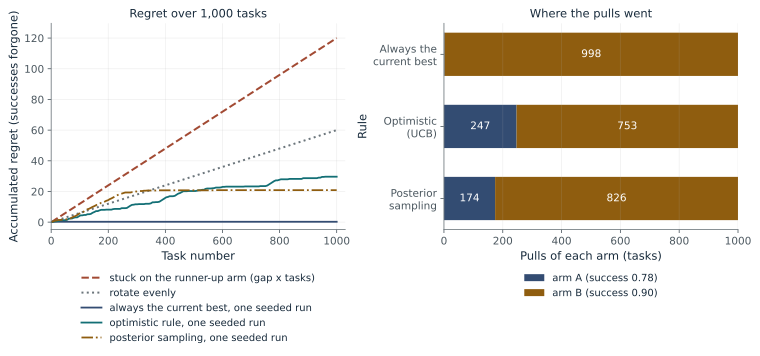

In [8]:
demo_id = 'C11-D01'
demo_controls = {'world': 'book', 'scale': 'own'}
demo_result = run_demo(11, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **World** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Regret: what never looking again costs
Controls: {"world": "default", "scale": "own"}
Evidence: constructed teaching example

Calculated quantities:
Stuck on the runner-up arm: 36.00
Rotate evenly: 18.00
Always the current best (this run): 0.60
Optimistic rule (this run): 9.30
Posterior sampling (this run): 13.80
Always the current best, seeds above half the stuck line (of 200): 59
Mean regret over 200 seeds, always the current best: 11.02
Mean regret over 200 seeds, optimistic rule: 7.59
Mean regret over 200 seeds, posterior sampling: 4.09
Chance the best arm's first two pulls both fail: 0.09
Success rate a stuck agent would report: 0.40
Best success rate available: 0.70

Worked steps:
1. Gaps: best mean minus each arm's mean, arm A 0.30, arm B 0.00.
2. Pulls of each arm in this run: always the current best 2, 118; optimistic rule 31, 89; posterior sampling 46, 74.
3. Regret = sum of gap x pulls. Optimistic rule: 0.30 x 31 = 9.30.
4. Posterior sampling: 0.30 x 46 = 13.80.
5. Stuck lin

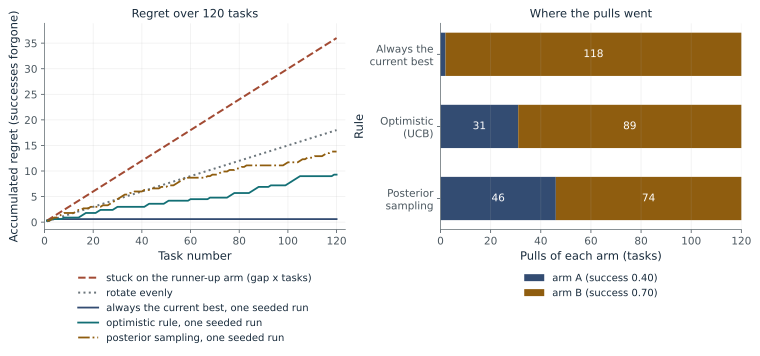

In [9]:
changed_controls = {'world': 'default', 'scale': 'own'}
changed_demo = run_demo(11, 'C11-D01', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [10]:
state_rows = []
for controls in demo_states(11, 'C11-D01'):
    state = run_demo(11, 'C11-D01', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "world": "book",
      "scale": "own"
    },
    "metrics": [
      [
        "Stuck on the runner-up arm",
        "120.00"
      ],
      [
        "Rotate evenly",
        "60.00"
      ],
      [
        "Always the current best (this run)",
        "0.24"
      ],
      [
        "Optimistic rule (this run)",
        "29.64"
      ],
      [
        "Posterior sampling (this run)",
        "20.88"
      ],
      [
        "Always the current best, seeds above half the stuck line (of 200)",
        "45"
      ],
      [
        "Mean regret over 200 seeds, always the current best",
        "28.05"
      ],
      [
        "Mean regret over 200 seeds, optimistic rule",
        "26.10"
      ],
      [
        "Mean regret over 200 seeds, posterior sampling",
        "6.31"
      ],
      [
        "Chance the chapter's controller draws two failures in a row from the best arm",
        "0.01"
      ],
      [
        "Success rate a stuck agent would rep

**Check your understanding:** If tool A succeeds 0.78 and tool B 0.90, how much regret does an agent that rotates evenly build up over 500 tasks?

[Answer and worked reasoning](../solutions/ch11.md#demonstration-1). [Matching browser demonstration](../readers/11-bounded-exploration/reader.html#C11-D01).

<a id="demo-c11-d02"></a>

### Demonstration 2: Optimism: why a thin record gets another call

Why does a tool with a poor record and few pulls get called again, and what changes that?

![Equation 11.2](../assets/math/b25daa0c3c98ef2794a7.svg)

**Symbols and units:** t is the number of completed pulls. N_t(a) is how many of those pulls went to tool a. mu-hat of a is tool a's average reward so far. c is the confidence coefficient; the book uses the square root of two, about 1.414, for rewards between 0 and 1. ln is the natural logarithm. The index is the mean plus the bonus c x sqrt(ln t / N_t(a)), and the tool with the larger index is called. Situations: pull 4 or pull 5 of the chapter's ten-pull table; the trapped controller after 20 tasks (A has 18 pulls and 14 successes, B has 2 pulls and none); the workbench problem (A has 80 pulls and mean 0.70, B has 20 pulls and mean 0.60).

The bonus grows slowly with the clock and shrinks as a tool is pulled, so a tool that is left alone gains bonus until it wins a call. In the trapped controller, B's two pulls give it a bonus of 1.731 against A's 0.577, enough to overturn a mean gap of 0.778. A smaller c shrinks every bonus: at c = 0.5 the same controller keeps calling A. If B then succeeds its estimate rises, and if it fails its count rises and its bonus shrinks; either way it is being updated again.

**Use in this chapter:** When a controller must choose among components with thin records, an index of this shape gives a written reason for each call, which can be audited, instead of a vague claim that the system is curious.

**Assumptions:** The table's rewards are the book's invented alternating sequence (A returns 1, 0, 1, 0, and so on; B returns 0, 1, 0, 1), not a test of the stochastic guarantee. Each tool is pulled once first, ties go to A, and the bonus uses unrounded values. Changing c changes the rule; the book's guarantee is stated for c equal to the square root of two with rewards in [0, 1]. The trapped controller and the workbench problem are single decisions given counts and means, not runs.

**Predict before running:** Pick pull 5 of the table with c = 1.414 (square root of 2). Tool B has a mean of 0.000 and tool A has 0.667. Does the rule call A or B?

**Controls you can change:**

- **Situation:** `situation` accepts 'p4', 'p5', 'trap', 'bench'.
- **Confidence coefficient c:** `c` accepts 1.4142135623730951, 1.0, 0.5.

**Source section:** A proved rule and ten constructed pulls.

**Evidence:** constructed teaching example.

Constructed example: the chapter's ten-pull table with c equal to the square root of two (invented teaching rewards), the chapter's trapped controller (18 pulls with 14 successes, 2 pulls with none) and the original workbench problem III.1 (80 and 20 pulls); the values of c other than the square root of two are defined for this reader.

Prediction choices:

1. Tool A, because its mean is higher.
2. Tool B, because its bonus is larger than the gap in means.

**Boundary of the conclusion:** Equation (11.2) requires a constant whose right value depends on the payoff scale.

**Common wrong turn:** The chapter's trapped controller drew two failures from a nine-in-ten process, and its rule contained no reason to look again: once a tool's estimate falls low enough to stop being selected, nothing will update it. The failure is in the loop from estimates to choices to data, not in the arithmetic of the estimate.

Optimism: why a thin record gets another call
Controls: {"situation": "p4", "c": 1.4142135623730951}
Evidence: constructed teaching example

Calculated quantities:
Counts A, B: 2, 1
Index A: 1.548
Index B: 1.482
Selected: A
Selected by mean alone: A
Reward seen after the pull: 1

Worked steps:
1. Completed pulls t = 3, so ln t = ln 3 = 1.099.
2. A: bonus = 1.414 x sqrt(1.099 / 2) = 1.048, index = 0.500 + 1.048 = 1.548.
3. B: bonus = 1.414 x sqrt(1.099 / 1) = 1.482, index = 0.000 + 1.482 = 1.482.
4. Tool A has the larger index by 0.066, so Equation (11.2) selects it. Its pull number 4 then returns 1. Ranking by mean alone would also select A, so here the bonus does not change the call.

With 3 completed pulls, ln 3 = 1.099. A: bonus = 1.414 x sqrt(1.099 / 2) = 1.048, index = 0.500 + 1.048 = 1.548. B: bonus = 1.414 x sqrt(1.099 / 1) = 1.482, index = 0.000 + 1.482 = 1.482. Tool A has the larger index by 0.066, so Equation (11.2) selects it. Its pull number 4 then returns 1. Ranking by mea

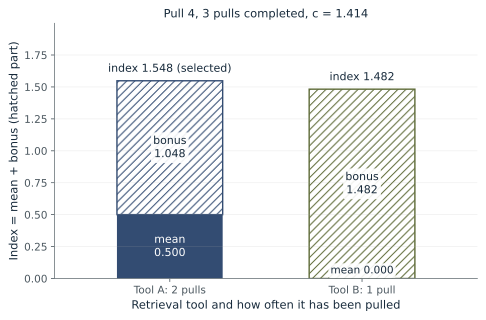

In [11]:
demo_id = 'C11-D02'
demo_controls = {'situation': 'p4', 'c': 1.4142135623730951}
demo_result = run_demo(11, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Situation** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Optimism: why a thin record gets another call
Controls: {"situation": "p5", "c": 1.4142135623730951}
Evidence: constructed teaching example

Calculated quantities:
Counts A, B: 3, 1
Index A: 1.628
Index B: 1.665
Selected: B
Selected by mean alone: A
Reward seen after the pull: 1

Worked steps:
1. Completed pulls t = 4, so ln t = ln 4 = 1.386.
2. A: bonus = 1.414 x sqrt(1.386 / 3) = 0.961, index = 0.667 + 0.961 = 1.628.
3. B: bonus = 1.414 x sqrt(1.386 / 1) = 1.665, index = 0.000 + 1.665 = 1.665.
4. Tool B has the larger index by 0.037, so Equation (11.2) selects it. Its pull number 5 then returns 1. Ranking by mean alone would select A (0.667 against 0.000); the bonus is what lets B in.

With 4 completed pulls, ln 4 = 1.386. A: bonus = 1.414 x sqrt(1.386 / 3) = 0.961, index = 0.667 + 0.961 = 1.628. B: bonus = 1.414 x sqrt(1.386 / 1) = 1.665, index = 0.000 + 1.665 = 1.665. Tool B has the larger index by 0.037, so Equation (11.2) selects it. Its pull number 5 then returns 1. Ranking by m

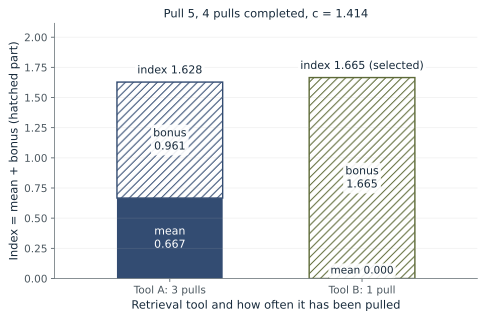

In [12]:
changed_controls = {'situation': 'p5', 'c': 1.4142135623730951}
changed_demo = run_demo(11, 'C11-D02', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [13]:
state_rows = []
for controls in demo_states(11, 'C11-D02'):
    state = run_demo(11, 'C11-D02', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "situation": "p4",
      "c": 1.4142135623730951
    },
    "metrics": [
      [
        "Counts A, B",
        "2, 1"
      ],
      [
        "Index A",
        "1.548"
      ],
      [
        "Index B",
        "1.482"
      ],
      [
        "Selected",
        "A"
      ],
      [
        "Selected by mean alone",
        "A"
      ],
      [
        "Reward seen after the pull",
        "1"
      ]
    ]
  },
  {
    "controls": {
      "situation": "p4",
      "c": 1.0
    },
    "metrics": [
      [
        "Counts A, B",
        "2, 1"
      ],
      [
        "Index A",
        "1.241"
      ],
      [
        "Index B",
        "1.048"
      ],
      [
        "Selected",
        "A"
      ],
      [
        "Selected by mean alone",
        "A"
      ],
      [
        "Reward seen after the pull",
        "1"
      ]
    ]
  },
  {
    "controls": {
      "situation": "p4",
      "c": 0.5
    },
    "metrics": [
      [
        "Counts A, B"

**Check your understanding:** At pull 5 of the table the counts are 3 and 1 after 4 completed pulls. With c = 1.414, what is B's bonus?

[Answer and worked reasoning](../solutions/ch11.md#demonstration-2). [Matching browser demonstration](../readers/11-bounded-exploration/reader.html#C11-D02).

<a id="demo-c11-d03"></a>

### Demonstration 3: Information gain is not decision value

Can a check remove uncertainty about a claim and still be worth exactly nothing?

![Equation 11.3](../assets/math/638761b25c1352586c4f.svg)

![Equation 11.4](../assets/math/f9f2ae99c3d3c2206ea0.svg)

**Symbols and units:** Y is the proposition the decision turns on: every claim in the draft is supported. O is the report of a check. H is entropy in bits, a measure of uncertainty (1 bit for a fair coin, 0 when certain). I(Y; O) is the uncertainty about Y that O removes. VOI is the decision value: the average best expected utility with the report, minus the best without it. Releasing scores 100 if supported and 0 if not; requesting evidence scores 92.

Entropy falls whenever the report is correlated with the claim, so the gain is positive. The value in Equation (11.4) is positive only if some report pushes the release score across the fixed value 92 of the alternative. When the reports leave the release score on the same side of 92 as the no-check score, the same action wins either way and VOI is zero, as at accuracy 0.60 with prior 0.85. Where that line falls depends on the prior: accuracy 0.70 is enough at prior 0.85 but not at prior 0.97, and at prior 0.50 only the 0.95 check lifts the score above 92.

**Use in this chapter:** Before paying for a check, write down which action follows each possible report. If it is the same action every time, the check is decoration, however interesting its output.

**Assumptions:** A symmetric check (equally accurate on supported and unsupported claims), a single decision between releasing and requesting evidence, and a belief that the stated prior and accuracy are correct. Accuracy and prior here are constructed; a real check may be biased in one direction, which this model does not cover.

**Predict before running:** With prior 0.85 and a check that is right 0.60 of the time, does the check remove uncertainty, and does it change what the agent does?

**Controls you can change:**

- **How often the check is right:** `accuracy` accepts 0.6, 0.7, 0.85, 0.95.
- **Prior chance the claims are supported:** `prior` accepts 0.5, 0.85, 0.97.

**Source section:** The condition that makes information worthless.

**Evidence:** constructed teaching example.

Constructed example: the book's release score 85 and evidence score 92 (Table 6.1 values); the checks, their accuracies and the priors are defined for this reader.

Prediction choices:

1. It removes uncertainty and changes the action.
2. It removes uncertainty but does not change the action.
3. It removes no uncertainty.

**Boundary of the conclusion:** Equation (11.4) prices a single observation against a fixed decision, not a sequence of them. All numbers in the opening construction are invented for teaching.

**Common wrong turn:** The chapter says a rule that seeks uncertainty as such will happily spend a budget resolving the number of words in a passage, which is uncertain, cheaply resolved and irrelevant. What the agent wants is uncertainty reduction about the quantity the decision turns on, and information has value only when it could change what the agent does.

Information gain is not decision value
Controls: {"accuracy": 0.85, "prior": 0.85}
Evidence: constructed teaching example

Calculated quantities:
Uncertainty before, H(Y): 0.610 bits
Uncertainty after, H(Y | O): 0.401 bits
Information gain I(Y; O): 0.209 bits
Decision value VOI: 3.71
Best action changes: yes

Worked steps:
1. Before the check: H(Y) = 0.610 bits; best action now = max(85.00, 92) = 92.00.
2. Report supported (chance 0.7450): posterior 0.9698, release scores 96.98 against 92.
3. Report unsupported (chance 0.2550): posterior 0.5000, release scores 50.00 against 92.
4. After the check: H(Y | O) = 0.401 bits, so the gain is 0.610 - 0.401 = 0.209 bits.
5. Value: 95.71 - 92.00 = 3.71.

Best action without the check = max(100 x 0.85, 92) = max(85.00, 92.00) = 92.00. supported report (chance 0.7450, posterior release score 96.98): weighted by that chance, max(100 x 0.7225, 92 x 0.7450) = max(72.25, 68.54) = 72.25; unsupported report (chance 0.2550, posterior release score 50.00)

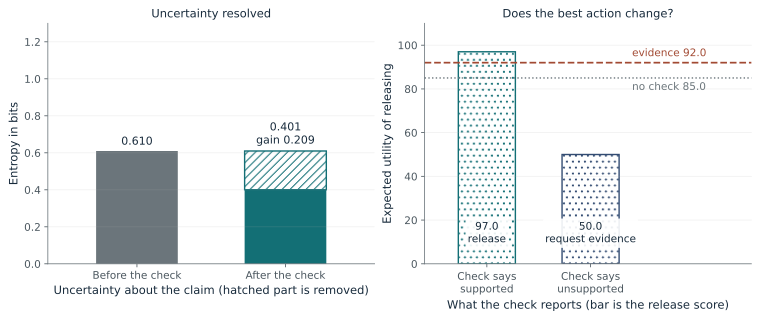

In [14]:
demo_id = 'C11-D03'
demo_controls = {'accuracy': 0.85, 'prior': 0.85}
demo_result = run_demo(11, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **How often the check is right** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Information gain is not decision value
Controls: {"accuracy": 0.6, "prior": 0.85}
Evidence: constructed teaching example

Calculated quantities:
Uncertainty before, H(Y): 0.610 bits
Uncertainty after, H(Y | O): 0.595 bits
Information gain I(Y; O): 0.015 bits
Decision value VOI: 0.00
Best action changes: no

Worked steps:
1. Before the check: H(Y) = 0.610 bits; best action now = max(85.00, 92) = 92.00.
2. Report supported (chance 0.5700): posterior 0.8947, release scores 89.47 against 92.
3. Report unsupported (chance 0.4300): posterior 0.7907, release scores 79.07 against 92.
4. After the check: H(Y | O) = 0.595 bits, so the gain is 0.610 - 0.595 = 0.015 bits.
5. Value: 92.00 - 92.00 = 0.00.

Best action without the check = max(100 x 0.85, 92) = max(85.00, 92.00) = 92.00. supported report (chance 0.5700, posterior release score 89.47): weighted by that chance, max(100 x 0.5100, 92 x 0.5700) = max(51.00, 52.44) = 52.44; unsupported report (chance 0.4300, posterior release score 79.07): 

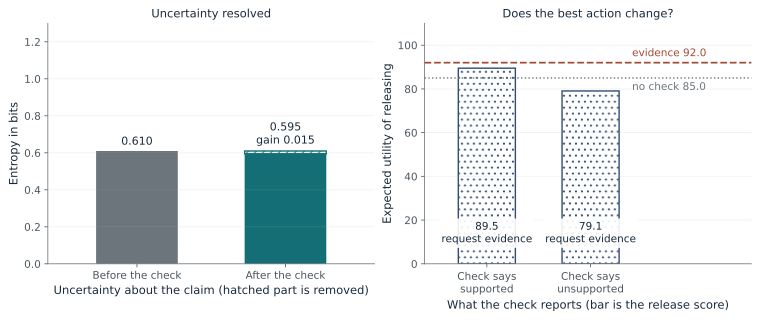

In [15]:
changed_controls = {'accuracy': 0.6, 'prior': 0.85}
changed_demo = run_demo(11, 'C11-D03', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [16]:
state_rows = []
for controls in demo_states(11, 'C11-D03'):
    state = run_demo(11, 'C11-D03', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "accuracy": 0.6,
      "prior": 0.5
    },
    "metrics": [
      [
        "Uncertainty before, H(Y)",
        "1.000 bits"
      ],
      [
        "Uncertainty after, H(Y | O)",
        "0.971 bits"
      ],
      [
        "Information gain I(Y; O)",
        "0.029 bits"
      ],
      [
        "Decision value VOI",
        "0.00"
      ],
      [
        "Best action changes",
        "no"
      ]
    ]
  },
  {
    "controls": {
      "accuracy": 0.6,
      "prior": 0.85
    },
    "metrics": [
      [
        "Uncertainty before, H(Y)",
        "0.610 bits"
      ],
      [
        "Uncertainty after, H(Y | O)",
        "0.595 bits"
      ],
      [
        "Information gain I(Y; O)",
        "0.015 bits"
      ],
      [
        "Decision value VOI",
        "0.00"
      ],
      [
        "Best action changes",
        "no"
      ]
    ]
  },
  {
    "controls": {
      "accuracy": 0.6,
      "prior": 0.97
    },
    "metrics": [
      [
        

**Check your understanding:** With prior 0.85 and a check that is right 0.70 of the time, a report of unsupported leaves the release score at 70.8. Does that report change the action?

[Answer and worked reasoning](../solutions/ch11.md#demonstration-3). [Matching browser demonstration](../readers/11-bounded-exploration/reader.html#C11-D03).

<a id="demo-c11-d04"></a>

### Demonstration 4: A worked price for one observation

How much is one call to a classifier worth, and how can the same classifier be worth zero in one decision and something in another?

![Equation 11.4](../assets/math/f9f2ae99c3d3c2206ea0.svg)

**Symbols and units:** A classifier reports flag with probability one third and clear with probability two thirds. Releasing scores 75 after flag and 90 after clear, plus the shift you choose; requesting evidence scores 92 either way. VOI is the average best score with the report minus the best score without it. The call cost is subtracted to give the net value. The book's price is 7/3, about 2.333.

With no shift, evidence wins under both reports and the value is exactly zero. A shift of 10 pushes the release score above 92 after clear but not after flag, so the best action now depends on the report. From a shift of 10 on, releasing already beats requesting evidence before observing (95 at shift 10), so the call can only rescue the flag branch. At a shift of 15 that branch still scores 90 against 92, so the call adds only 1/3 x (92 - 90) = 0.667. At a call cost of exactly 7/3 the shift-10 call ties with skipping it.

**Use in this chapter:** Price a verification step against the specific decision it feeds. The same step, with the same accuracy and cost, can be a bargain for one decision and worthless for another. Before spending any budget, also check whether the system already holds the answer in a log it failed to structure: free information should always be used.

**Assumptions:** One decision, one observation, a coherent probability model, and a gross value that ignores any later decisions the observation could also inform. The conditional release scores are the book's constructed values; a real classifier's scores would have to be estimated, and a wrong estimate can flip the verdict.

**Predict before running:** Add 10 to the release scores. Does the classifier become worth buying at a call cost of 2?

**Controls you can change:**

- **Added to both release scores:** `shift` accepts 0, 5, 10, 15.
- **Cost of the call:** `call_cost` accepts 0, 2, 2.3333333333333335.

**Source section:** A worked price for one observation.

**Evidence:** constructed teaching example.

Constructed example: the book's worked classifier (flag one third, release scores 75 and 90, evidence 92, shift 10 giving 7/3); the other shifts and costs are defined for this reader.

Prediction choices:

1. No: gross value is 2.0, so the net value is 0.
2. Yes: gross value is 7/3 = 2.333, above 2, so the net value is 0.333.
3. No: the classifier is worth exactly zero.

**Boundary of the conclusion:** Equation (11.4) prices a single observation against a fixed decision, not a sequence of them.

**Common wrong turn:** The chapter says an agent that runs a call whose result cannot change its action is not being thorough: it is failing to distinguish what the call would tell it from what it would do differently. The call has a real cost, a real information gain and zero value.

A worked price for one observation
Controls: {"shift": 10, "call_cost": 0}
Evidence: constructed teaching example

Calculated quantities:
Release now, no observation: 95.000
Best action without the call: 95.000
Best expected utility with the call: 97.333
Gross value: 2.333
Net value: 2.333
Worth buying: yes

Worked steps:
1. Release scores 85 after flag and 100 after clear; requesting evidence scores 92 either way.
2. Without the call: 1/3 x 85 + 2/3 x 100 = 95.000, best = 95.000.
3. With the call: 1/3 x 92 + 2/3 x 100 = 97.333.
4. Gross value = 97.333 - 95.000 = 2.333.
5. Net value = 2.333 - 0.0 = 2.333.

Release scores 85 after flag and 100 after clear, so before observing it scores 1/3 x 85 + 2/3 x 100 = 95.000 against 92 for requesting evidence. With the call the best choices are 92 after flag and 100 after clear, so 1/3 x 92 + 2/3 x 100 = 97.333. Gross value = 97.333 - 95.000 = 2.333; net value = 2.333 - 0.0 = 2.333. Net value is positive, so the call is worth buying for this one 

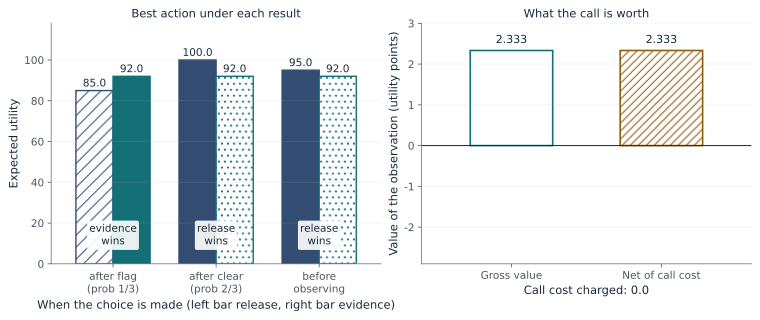

In [17]:
demo_id = 'C11-D04'
demo_controls = {'shift': 10, 'call_cost': 0}
demo_result = run_demo(11, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Added to both release scores** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

A worked price for one observation
Controls: {"shift": 0, "call_cost": 0}
Evidence: constructed teaching example

Calculated quantities:
Release now, no observation: 85.000
Best action without the call: 92.000
Best expected utility with the call: 92.000
Gross value: 0.000
Net value: 0.000
Worth buying: no

Worked steps:
1. Release scores 75 after flag and 90 after clear; requesting evidence scores 92 either way.
2. Without the call: 1/3 x 75 + 2/3 x 90 = 85.000, best = 92.000.
3. With the call: 1/3 x 92 + 2/3 x 92 = 92.000.
4. Gross value = 92.000 - 92.000 = 0.000.
5. Net value = 0.000 - 0.0 = 0.000.

Release scores 75 after flag and 90 after clear, so before observing it scores 1/3 x 75 + 2/3 x 90 = 85.000 against 92 for requesting evidence. With the call the best choices are 92 after flag and 92 after clear, so 1/3 x 92 + 2/3 x 92 = 92.000. Gross value = 92.000 - 92.000 = 0.000; net value = 0.000 - 0.0 = 0.000. Gross value is zero: the same action wins after either result, so no pric

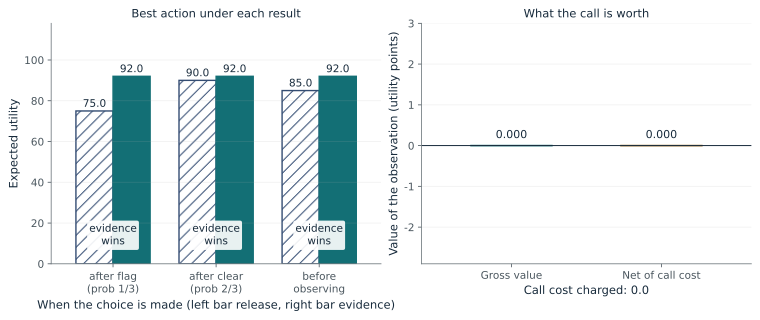

In [18]:
changed_controls = {'shift': 0, 'call_cost': 0}
changed_demo = run_demo(11, 'C11-D04', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [19]:
state_rows = []
for controls in demo_states(11, 'C11-D04'):
    state = run_demo(11, 'C11-D04', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "shift": 0,
      "call_cost": 0
    },
    "metrics": [
      [
        "Release now, no observation",
        "85.000"
      ],
      [
        "Best action without the call",
        "92.000"
      ],
      [
        "Best expected utility with the call",
        "92.000"
      ],
      [
        "Gross value",
        "0.000"
      ],
      [
        "Net value",
        "0.000"
      ],
      [
        "Worth buying",
        "no"
      ]
    ]
  },
  {
    "controls": {
      "shift": 0,
      "call_cost": 2
    },
    "metrics": [
      [
        "Release now, no observation",
        "85.000"
      ],
      [
        "Best action without the call",
        "92.000"
      ],
      [
        "Best expected utility with the call",
        "92.000"
      ],
      [
        "Gross value",
        "0.000"
      ],
      [
        "Net value",
        "-2.000"
      ],
      [
        "Worth buying",
        "no"
      ]
    ]
  },
  {
    "controls": {
 

**Check your understanding:** With a shift of 5, what is the gross value, and is the call worth buying at cost 2?

[Answer and worked reasoning](../solutions/ch11.md#demonstration-4). [Matching browser demonstration](../readers/11-bounded-exploration/reader.html#C11-D04).

## Questions

1. Express default regret through counts.

2. Does common pull cost change arm pseudo-regret?

3. Express transfer regret.

Answers: [separate solutions](../solutions/ch11.md). Try the calculation before opening them.

## Summary

Greedy, UCB, and posterior sampling make different finite exploration choices. The notebook separates known-mean pseudo-regret from realized net reward and records the seed and pull counts. Swapped means and a three-arm transfer case test the calculation. Its conclusions are conditional on stationary independent Bernoulli rewards. A favorable run does not demonstrate universal policy superiority, and known simulator means must not be mistaken for calibrated deployed-tool estimates.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-11-bounded-exploration`](../skills/maa-11-bounded-exploration/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 11.1

![Equation 11.1](../assets/math/0748ee3073daf997794a.svg)

Equation (11.1) measures the total payoff an agent gave up over its run by not always taking the action it would have taken had it known which was best.

Multiply the best action's mean payoff by the number of rounds, then subtract the average total the agent actually collected.

LaTeX source, preserved for inspection:

```latex
\operatorname{Reg}(T)=T\mu^{\star}-\operatorname{E}\!\left[\sum_{t=0}^{T-1}\mu_{a_t}\right].
\tag{11.1}
```

### Equation 11.2

![Equation 11.2](../assets/math/b25daa0c3c98ef2794a7.svg)

Equation (11.2) ranks actions by an optimistic estimate rather than a best guess, so an action stays in contention while it remains poorly understood.

Add to each action's average payoff a bonus that grows as the run lengthens and shrinks as that action is tried more often, then take the largest sum.

LaTeX source, preserved for inspection:

```latex
a_t=\arg\max_{a\in\mathcal{A}}\left(\hat\mu_a+c\sqrt{\frac{\ln t}{N_t(a)}}\right).
\tag{11.2}
```

### Equation 11.3

![Equation 11.3](../assets/math/638761b25c1352586c4f.svg)

Equation (11.3) measures how much a candidate observation would reduce uncertainty about the specific quantity a decision depends on, rather than about anything at all.

Subtract the uncertainty remaining about the decision-relevant quantity after the observation from the uncertainty before it.

LaTeX source, preserved for inspection:

```latex
\operatorname{Gain}(O)=I(Y;O)=H(Y)-H(Y\mid O).
\tag{11.3}
```

### Equation 11.4

![Equation 11.4](../assets/math/f9f2ae99c3d3c2206ea0.svg)

Equation (11.4) prices an observation by comparing the best the agent could do knowing it against the best it can do without it.

Take the average, over possible observations, of the best expected utility available after seeing each one, then subtract the best expected utility available now.

LaTeX source, preserved for inspection:

```latex
\operatorname{VOI}(O)=\operatorname{E}_{O}\!\left[\max_{a}\operatorname{EU}(a\mid O)\right]-\max_{a}\operatorname{EU}(a).
\tag{11.4}
```